E-Commerce Product Analysis - November 2019 Dataset
Powered by DuckDB — no chunking, low RAM, full 9 GB dataset

In [3]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
 
warnings.filterwarnings("ignore")

CONFIGURATION

In [4]:
FILE_PATH  = r"C:\Users\nikes\Downloads\2019-Nov.csv\2019-Nov.csv"
OUTPUT_DIR = "product_analysis_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
con = duckdb.connect()
 
def q(sql):
    """Run SQL, return a pandas DataFrame."""
    return con.execute(sql).df()
 
# Reusable category expression (replaces the lambda in old code)
CAT_EXPR = "COALESCE(NULLIF(split_part(category_code, '.', 1), ''), 'unknown_category')"
BRAND_EXPR = "COALESCE(NULLIF(brand, ''), 'unknown_brand')"
 
print("=" * 60)
print("  DuckDB E-Commerce Analysis – November 2019")
print("=" * 60)
print(f"  Reading from : {FILE_PATH}")
print(f"  Outputs to   : ./{OUTPUT_DIR}/\n")

  DuckDB E-Commerce Analysis – November 2019
  Reading from : C:\Users\nikes\Downloads\2019-Nov.csv\2019-Nov.csv
  Outputs to   : ./product_analysis_output/



DATASET OVERVIEW

In [7]:
print("─" * 60)
print("DATASET OVERVIEW")
print("─" * 60)
 
overview = q(f"""
    SELECT
        COUNT(*)                                      AS total_rows,
        COUNT(DISTINCT product_id)                    AS unique_products,
        COUNT(DISTINCT user_id)                       AS unique_users,
        MIN(event_time::TIMESTAMP)                    AS earliest,
        MAX(event_time::TIMESTAMP)                    AS latest,
        COUNT(*) FILTER (WHERE category_code IS NULL) AS missing_category,
        COUNT(*) FILTER (WHERE brand IS NULL)         AS missing_brand
    FROM read_csv_auto('{FILE_PATH}')
""")
 
total_rows = int(overview["total_rows"][0])
print(overview.T.to_string(header=False))

────────────────────────────────────────────────────────────
DATASET OVERVIEW
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

total_rows                   67501979
unique_products                190662
unique_users                  3696117
earliest          2019-11-01 00:00:00
latest            2019-11-30 23:59:59
missing_category             21898171
missing_brand                 9218235


Missing Value analysis

In [9]:
print("MISSING VALUE ANALYSIS")
 
missing_cat  = int(overview["missing_category"][0])
missing_brand = int(overview["missing_brand"][0])
 
print(f"  category_code  : {missing_cat:>10,}  ({missing_cat/total_rows*100:.1f}%)")
print(f"  brand          : {missing_brand:>10,}  ({missing_brand/total_rows*100:.1f}%)")
print("  ✔ Handled in queries via COALESCE → 'unknown_category' / 'unknown_brand'")

MISSING VALUE ANALYSIS
  category_code  : 21,898,171  (32.4%)
  brand          :  9,218,235  (13.7%)
  ✔ Handled in queries via COALESCE → 'unknown_category' / 'unknown_brand'


EVENT TYPE DISTRIBUTION


────────────────────────────────────────────────────────────
EVENT TYPE DISTRIBUTION
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type
view        63556110
cart         3028930
purchase      916939


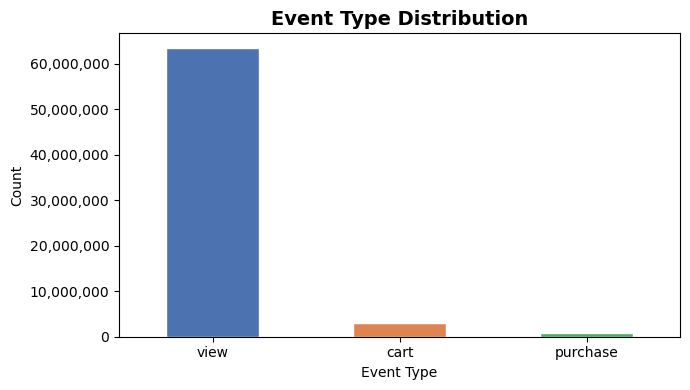

In [ ]:
print("EVENT TYPE DISTRIBUTION")
print("─" * 60)
 
event_df = q(f"""
    SELECT event_type, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    GROUP BY event_type
    ORDER BY count DESC
""")
event_counts = event_df.set_index("event_type")["count"]
print(event_counts.to_string())
 
fig, ax = plt.subplots(figsize=(7, 4))
event_counts.plot(kind="bar", ax=ax,
                  color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                  edgecolor="white")
ax.set_title("Event Type Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Event Type"); ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=0); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/01_event_type_distribution.png", dpi=150)
plt.show(); 
plt.close()

CONVERSION FUNNEL

CONVERSION FUNNEL
────────────────────────────────────────────────────────────
  Views         :   63,556,110
  Carts         :    3,028,930  (4.77% of views)
  Purchases     :      916,939  (30.27% of carts)
  Overall Conv. :                  1.44% (view→purchase)


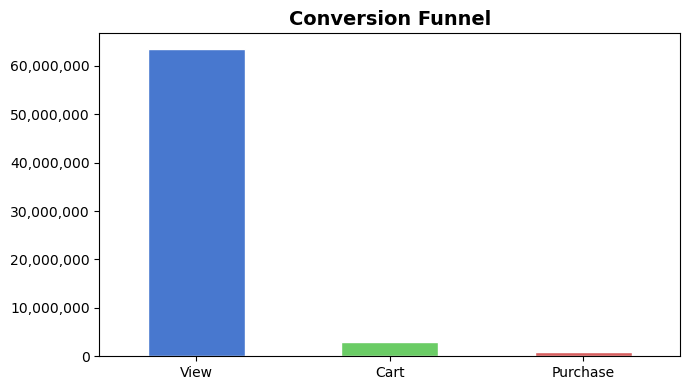

In [11]:
print("CONVERSION FUNNEL")
print("─" * 60)
 
views     = int(event_counts.get("view", 0))
carts     = int(event_counts.get("cart", 0))
purchases = int(event_counts.get("purchase", 0))
 
view_to_cart     = carts     / views     * 100 if views else 0
cart_to_purchase = purchases / carts     * 100 if carts else 0
view_to_purchase = purchases / views     * 100 if views else 0
 
print(f"  Views         : {views:>12,}")
print(f"  Carts         : {carts:>12,}  ({view_to_cart:.2f}% of views)")
print(f"  Purchases     : {purchases:>12,}  ({cart_to_purchase:.2f}% of carts)")
print(f"  Overall Conv. :                  {view_to_purchase:.2f}% (view→purchase)")
 
funnel_data = pd.Series({"View": views, "Cart": carts, "Purchase": purchases})
fig, ax = plt.subplots(figsize=(7, 4))
funnel_data.plot(kind="bar", ax=ax,
                 color=["#4878CF","#6ACC65","#D65F5F"], edgecolor="white")
ax.set_title("Conversion Funnel", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=0); plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/02_conversion_funnel.png", dpi=150)
plt.show(); 
plt.close()

Top Categories


────────────────────────────────────────────────────────────
TOP CATEGORIES
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Top 10 by Views:
main_category
electronics         21988192
unknown_category    20837460
appliances           8037980
computers            4029049
apparel              2942622
furniture            2058798
auto                 1164278
construction         1047072
kids                  779517
accessories           380373

Top 10 by Purchases:
main_category
electronics         493639
unknown_category    234218
appliances           99026
computers            34477
apparel              14215
furniture            11542
auto                 10719
construction          8699
kids                  6166
accessories           2154


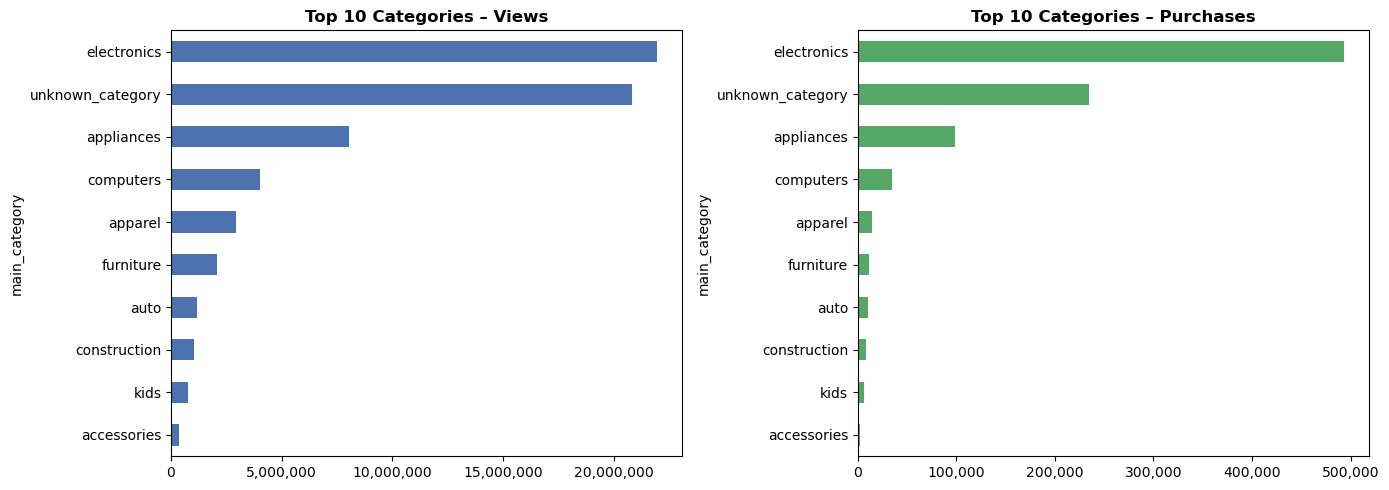

In [13]:
print("\n" + "─" * 60)
print("TOP CATEGORIES")
print("─" * 60)
 
cat_views = q(f"""
    SELECT {CAT_EXPR} AS main_category, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'view'
    GROUP BY 1 ORDER BY count DESC LIMIT 10
""").set_index("main_category")["count"]
 
cat_purchases = q(f"""
    SELECT {CAT_EXPR} AS main_category, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase'
    GROUP BY 1 ORDER BY count DESC LIMIT 10
""").set_index("main_category")["count"]
 
print("\nTop 10 by Views:");    print(cat_views.to_string())
print("\nTop 10 by Purchases:"); print(cat_purchases.to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_views.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 10 Categories – Views", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
 
cat_purchases.sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Top 10 Categories – Purchases", fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/03_top_categories.png", dpi=150)
plt.show(); 
plt.close()

Top Brands


────────────────────────────────────────────────────────────
TOP BRANDS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Top 15 Brands by Purchases:
brand
samsung     200027
apple       166064
xiaomi       68292
huawei       23703
cordiant     16983
oppo         15080
lucente      14559
lg           12879
sony         10309
artel         9267
bosch         8010
lenovo        6547
acer          6402
nokian        5981
viatti        5578


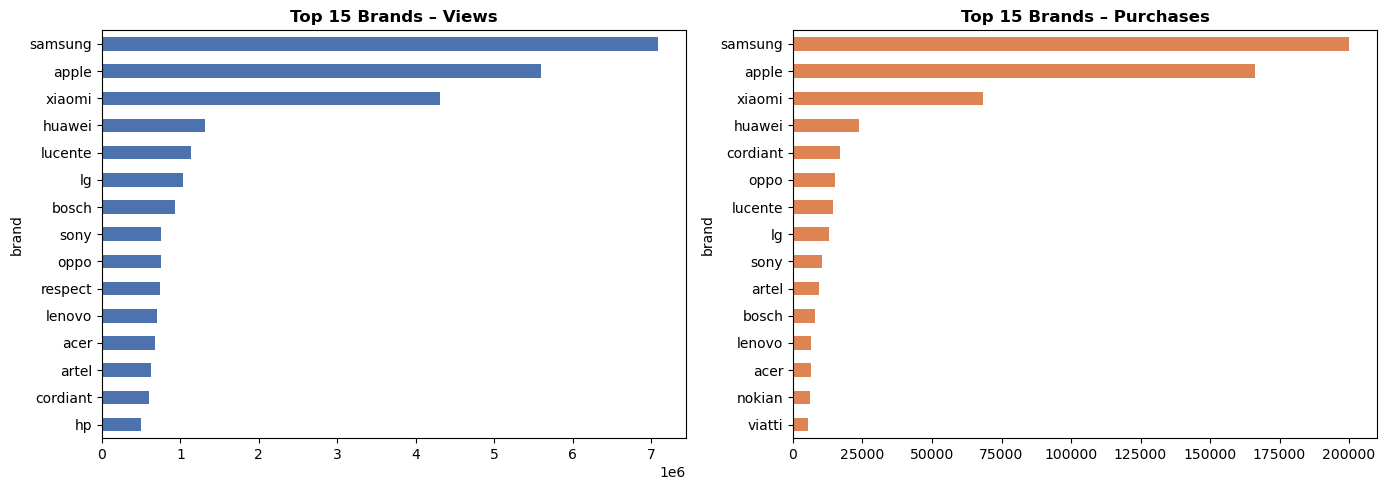

In [14]:
print("\n" + "─" * 60)
print("TOP BRANDS")
print("─" * 60)
 
brand_views = q(f"""
    SELECT {BRAND_EXPR} AS brand, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'view' AND brand IS NOT NULL
    GROUP BY 1 ORDER BY count DESC LIMIT 15
""").set_index("brand")["count"]
 
brand_purchases = q(f"""
    SELECT {BRAND_EXPR} AS brand, COUNT(*) AS count
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND brand IS NOT NULL
    GROUP BY 1 ORDER BY count DESC LIMIT 15
""").set_index("brand")["count"]
 
print("\nTop 15 Brands by Purchases:"); print(brand_purchases.to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
brand_views.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 15 Brands – Views", fontweight="bold")
 
brand_purchases.sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Top 15 Brands – Purchases", fontweight="bold")
 
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/04_top_brands.png", dpi=150)
plt.show(); plt.close()

As Above shown in the picture, you can see 'cordiant' have less views than many brands but is above in purchased section than many companies


--PRICE ANALYSIS--


────────────────────────────────────────────────────────────
PRICE ANALYSIS
────────────────────────────────────────────────────────────


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type  min     max   mean    std  median
      cart 0.77 2574.07 290.40 335.00  168.70
  purchase 0.77 2574.07 300.12 341.38  169.96
      view 0.77 2574.07 293.31 357.00  166.03


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

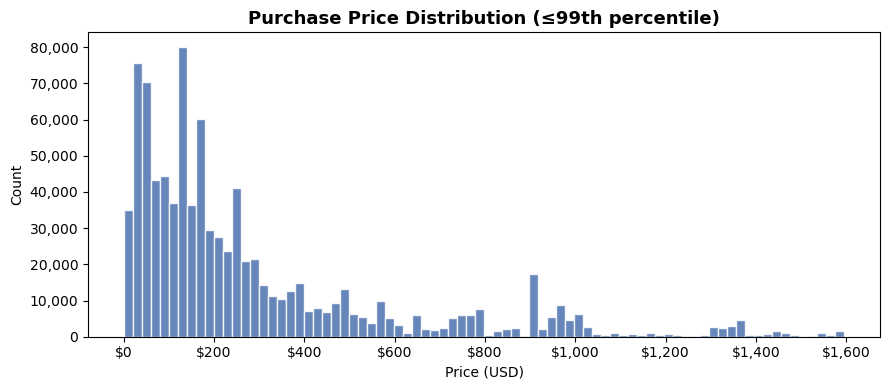

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

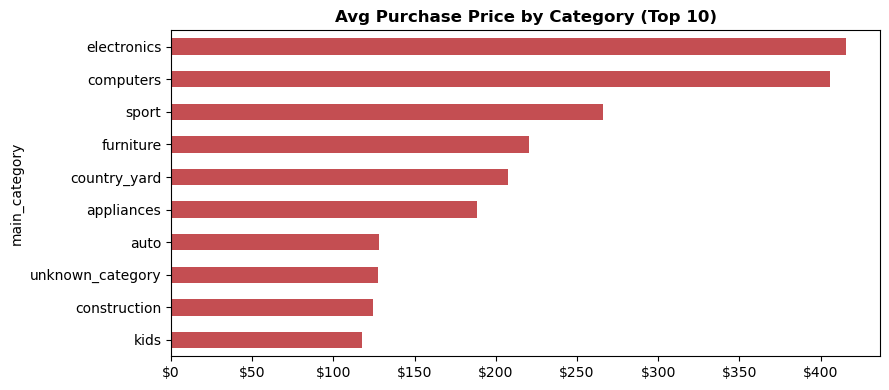

In [15]:
print("\n" + "─" * 60)
print("PRICE ANALYSIS")
print("─" * 60)
 
price_stats = q(f"""
    SELECT event_type,
           ROUND(MIN(price),2)    AS min,
           ROUND(MAX(price),2)    AS max,
           ROUND(AVG(price),2)    AS mean,
           ROUND(STDDEV(price),2) AS std,
           ROUND(MEDIAN(price),2) AS median
    FROM read_csv_auto('{FILE_PATH}')
    WHERE price > 0
    GROUP BY event_type ORDER BY event_type
""")
print(price_stats.to_string(index=False))
 
# Price distribution – fetch purchase prices as a small sample for histogram
p99 = float(q(f"""
    SELECT PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY price) AS p99
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND price > 0
""")["p99"][0])
 
purchase_prices = q(f"""
    SELECT price FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND price > 0 AND price <= {p99}
""")["price"]
 
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(purchase_prices, bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_title("Purchase Price Distribution (≤99th percentile)", fontsize=13, fontweight="bold")
ax.set_xlabel("Price (USD)"); ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/05_purchase_price_dist.png", dpi=150)
plt.show(); plt.close()
 
avg_price_cat = q(f"""
    SELECT {CAT_EXPR} AS main_category, ROUND(AVG(price),2) AS avg_price
    FROM read_csv_auto('{FILE_PATH}')
    WHERE event_type = 'purchase' AND price > 0
    GROUP BY 1 ORDER BY avg_price DESC LIMIT 10
""").set_index("main_category")["avg_price"]
 
fig, ax = plt.subplots(figsize=(9, 4))
avg_price_cat.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Avg Purchase Price by Category (Top 10)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/06_avg_price_by_category.png", dpi=150)
plt.show(); plt.close()